# 4. PCA and t-SNE
In this lab, we will go through PCA and t-SNE on MNIST dataset.

## MNIST dataset
The `mnist` package provides a function to load the MNIST dataset. The MNIST dataset is a dataset of handwritten digits. It has 60,000 training samples, and 10,000 test samples. Each image is represented by 28x28 pixels, each containing a value 0 - 255 with its grayscale value. The MNIST dataset is one of the most common datasets used for image classification and accessible from many different sources. See [MNIST dataset](http://yann.lecun.com/exdb/mnist/).

In [ ]:
!pip install python-mnist

In [ ]:
#### THe data were uploaded to a colab drive folder
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Navigate to the desired folder in Google Drive
folder_path = '/content/drive/My Drive/your_folder'


Mounted at /content/drive


In [ ]:
# load from mnist dataset: python-mnist
# train-images-idx3-ubyte.gz:  training set images (9912422 bytes)
# train-labels-idx1-ubyte.gz:  training set labels (28881 bytes)
# t10k-images-idx3-ubyte.gz:   test set images (1648877 bytes)
# t10k-labels-idx1-ubyte.gz:   test set labels (4542 bytes)
from mnist import MNIST
import os
# Initialize the dataset
# Navigate to the desired folder in Google Drive
mndata = MNIST('/content/drive/My Drive/datasets/MNIST/')
mndata.gz = True

# Load the dataset into memory (this will search the four files above)
training_images, training_labels = mndata.load_training()
testing_images, testing_labels = mndata.load_testing()

You can also import the MNIST dataset from `keras` package.
`keras` is a high-level neural networks API, written in Python and capable of running on top of TensorFlow, CNTK, or Theano.
It was developed with a focus on enabling fast experimentation.
Being able to go from idea to result with the least possible delay is key to doing good research.

In [26]:
from keras.datasets import mnist
# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 [==============================] - 0s 0us/step


Also, you can call the MNIST dataset from `pytorch` package.
PyTorch is an open source machine learning library based on the Torch library, used for applications such as computer vision and natural language processing, primarily developed by Facebook's AI Research lab (FAIR). It is free and open-source software released under the Modified BSD license.


In [27]:
import torch
import torchvision
import torchvision.transforms as transforms
# Load the MNIST dataset
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
trainset = torchvision.datasets.MNIST(root='./data', train=True,
                                      download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)
testset = torchvision.datasets.MNIST(root='./data', train=False,
                                     download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

100%|██████████| 9912422/9912422 [00:00<00:00, 103956690.86it/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 28881/28881 [00:00<00:00, 82125894.12it/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw



100%|██████████| 1648877/1648877 [00:00<00:00, 29098224.44it/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 18658696.15it/s]


Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



## Tasks
1. Load the MNIST dataset.
2. Apply PCA and t-SNE on the MNIST dataset. Try the test dataset. t-SNE is time-consuming, so you can use a subset of the dataset.
3. Visualize the results of PCA and t-SNE.
4. Compare the results of PCA and t-SNE.
5. Discuss the pros and cons of PCA and t-SNE.

## PCA
Principal Component Analysis (PCA) is a linear dimensionality reduction technique that can be utilized for extracting information from a high-dimensional space by projecting it into a lower-dimensional sub-space. It tries to preserve the essential parts that have more variation of the data and remove the non-essential parts with fewer variations. <br>
NOTE: the following is a template code. You need to change or modify the variable `X_train`.

In [34]:
print(X_train.shape)

(60000, 28, 28)


In [35]:
from sklearn.decomposition import PCA
# Create a Randomized PCA model that takes two components
randomized_pca = PCA(n_components=2, svd_solver='randomized')
# Reshape the data to 2 dimensions
X_train_2d = X_train.reshape(X_train.shape[0], -1)

# Fit and transform the data
reduced_data_rpca = randomized_pca.fit_transform(X_train_2d)


Have a look at the PCA results. Save the plot using `plt.savefig()` to a folder `labs/lab4` and name it `MNIST_PCA.png`.

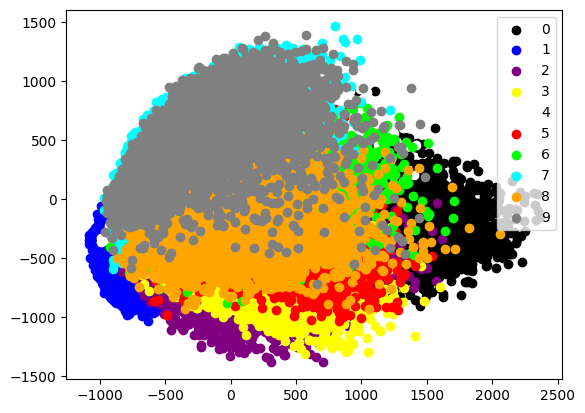

In [44]:
import matplotlib.pyplot as plt
# Plot the data
colors = ['black', 'blue', 'purple', 'yellow', 'white', 'red', 'lime', 'cyan', 'orange', 'gray']
for i in range(len(colors)):
    x = reduced_data_rpca[:, 0][y_train == i]
    y = reduced_data_rpca[:, 1][y_train == i]
    plt.scatter(x, y, c=colors[i])
plt.legend(list(map(str, range(10))))

# Save the plot to the specified folder and filename
save_folder = '/content/drive/My Drive/datasets/MNIST/'
save_filename = 'MNIST_PCA.png'
save_path = f'{save_folder}/{save_filename}'
plt.savefig(save_path)

plt.show()

## t-SNE
t-Distributed Stochastic Neighbor Embedding (t-SNE) is a non-linear dimensionality reduction algorithm used for exploring high-dimensional data. It maps multi-dimensional data to two or more dimensions suitable for human observation

In [42]:
from sklearn.manifold import TSNE
# Create a t-SNE model
tsne = TSNE(n_components=2, verbose=1, perplexity=40, n_iter=300)
# Fit and transform the data to the t-SNE model
tsne_results = tsne.fit_transform(X_train_2d)

[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 60000 samples in 0.047s...
[t-SNE] Computed neighbors for 60000 samples in 239.080s...
[t-SNE] Computed conditional probabilities for sample 1000 / 60000
[t-SNE] Computed conditional probabilities for sample 2000 / 60000
[t-SNE] Computed conditional probabilities for sample 3000 / 60000
[t-SNE] Computed conditional probabilities for sample 4000 / 60000
[t-SNE] Computed conditional probabilities for sample 5000 / 60000
[t-SNE] Computed conditional probabilities for sample 6000 / 60000
[t-SNE] Computed conditional probabilities for sample 7000 / 60000
[t-SNE] Computed conditional probabilities for sample 8000 / 60000
[t-SNE] Computed conditional probabilities for sample 9000 / 60000
[t-SNE] Computed conditional probabilities for sample 10000 / 60000
[t-SNE] Computed conditional probabilities for sample 11000 / 60000
[t-SNE] Computed conditional probabilities for sample 12000 / 60000
[t-SNE] Computed conditional probabilities for 

Have a look at the t-SNE results. Save the plot using `plt.savefig()` to a folder `labs/lab4` and name it `MNIST_tSNE.png`.

<ipython-input-45-7cc10c6b1616>:12: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_path)


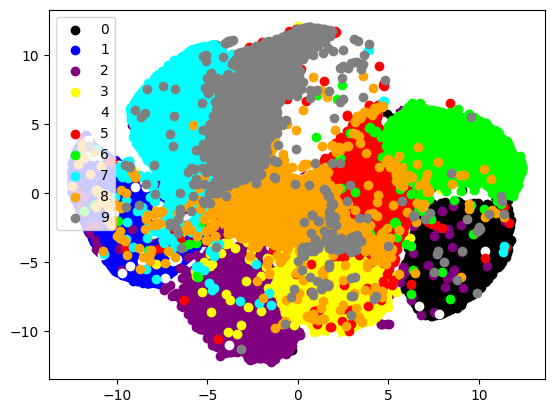

In [45]:
# Plot the data
colors = ['black', 'blue', 'purple', 'yellow', 'white', 'red', 'lime', 'cyan', 'orange', 'gray']
for i in range(len(colors)):
    x = tsne_results[:, 0][y_train == i]
    y = tsne_results[:, 1][y_train == i]
    plt.scatter(x, y, c=colors[i])
plt.legend(list(map(str, range(10))))
# Save the plot to the specified folder and filename
save_folder = '/content/drive/My Drive/datasets/MNIST/'
save_filename = 'MNIST_tSNE.png'
save_path = f'{save_folder}/{save_filename}'
plt.savefig(save_path)

plt.show()